# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")
df["status"] = df["status(keep/discard)"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 41
Columns: ['commit', 'accuracy', 'status(keep/discard)', 'description', 'status']


,commit,accuracy,status(keep/discard),description,status
0,720cd7b,0.8616,keep,"Baseline config, lr=1e-4, batch=8, rank=8, alp...",KEEP
1,eedea27,0.8793,keep,"LORA_RANK=16, LORA_ALPHA=32",KEEP
2,c93509d,0.8803,keep,"LR=2e-4, LORA_RANK=16, LORA_ALPHA=32",KEEP
3,7cc62fc,NaN,discard,"BATCH_SIZE=16, LR=2e-4, LORA_RANK=16, LORA_ALP...",DISCARD
4,46e74fb,0.8741,discard,Add warmup 10%,DISCARD
5,321d94a,0.8803,discard,"Lion optimizer, LR=5e-5",DISCARD
6,5d87d2f,0.8730,discard,"LR=3e-4, RANK=32, ALPHA=64",DISCARD
7,88b7801,0.8866,keep,"Muon optimizer, LR=2e-4, LORA_RANK=16, LORA_AL...",KEEP
8,cf97053,0.8814,discard,"Muon, RANK=32, ALPHA=64",DISCARD
9,0e3ae56,0.8762,discard,"Muon, LR=5e-4",DISCARD


In [10]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    33
KEEP        8

Keep rate: 8/41 = 19.5%


In [12]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    accuracy = row["accuracy"]
    desc = row["description"]
    print(f"  #{i:3d}  accuracy={accuracy:.6f}  {desc}")

KEPT experiments (8 total):

  #  0  accuracy=0.861600  Baseline config, lr=1e-4, batch=8, rank=8, alpha=16
  #  1  accuracy=0.879300  LORA_RANK=16, LORA_ALPHA=32
  #  2  accuracy=0.880300  LR=2e-4, LORA_RANK=16, LORA_ALPHA=32
  #  7  accuracy=0.886600  Muon optimizer, LR=2e-4, LORA_RANK=16, LORA_ALPHA=32
  # 10  accuracy=0.891800  Muon, LR=1e-4
  # 15  accuracy=0.893900  Muon, RANK=24, ALPHA=48
  # 27  accuracy=0.898000  Muon, RANK=24, ALPHA=48, clip=1.0
  # 32  accuracy=0.902200  Muon, RANK=32, ALPHA=48, clip=1.0


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

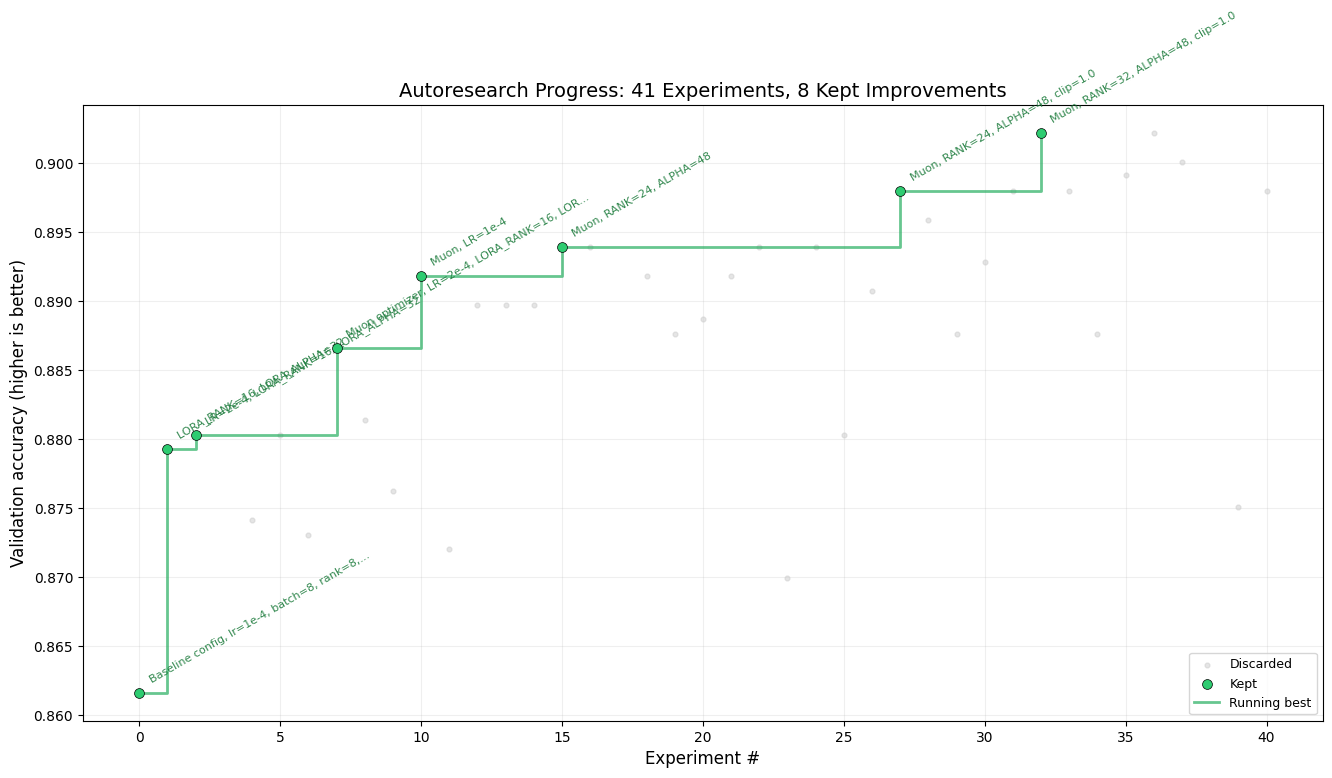

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_accuracy = valid.loc[0, "accuracy"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["accuracy"] >= baseline_accuracy - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["accuracy"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["accuracy"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_accuracy = valid.loc[kept_mask, "accuracy"]
running_max = kept_accuracy.cummax() # Changed to cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, accuracy in zip(kept_idx, kept_accuracy):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, accuracy),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")
    
# Fixed fallback variable from baseline_bpb to baseline_accuracy
best = running_max.iloc[-1] if len(running_max) > 0 else baseline_accuracy
n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation accuracy (higher is better)", fontsize=12) # Updated label
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9) # Moved to lower right so the rising line doesn't collide with it
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_accuracy) * 0.15
# Added absolute value fallback just in case best == baseline

## Summary Statistics

In [ ]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["accuracy"]
best_bpb = kept["accuracy"].min()
best_row = kept.loc[kept["accuracy"].idxmin()]

print(f"Baseline accuracy:  {baseline_bpb:.6f}")
print(f"Best accuracy:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['accuracy']:.6f}  {desc}")

## Top Hits (Kept Experiments by Improvement)

In [ ]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["accuracy"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["accuracy"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['accuracy']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")